# Exploratory data analysis

What this notebook is for: establishing the facts the modelling decisions rest on.

1. **Nominal vs actual survival** for all five corpora — the table that determines
   how big the Task 4 retrieval gallery actually is.
2. **Tag frequency long tail** — why macro-F1 and not accuracy, and why synonyms
   are merged before the top-50 cut.
3. **Clip duration distributions** — why the segmentation window is 3 s.
4. **Tag co-occurrence** — which tags are near-duplicates in practice.
5. **Sample graph renders** — what the GNN actually sees.

Run `python scripts/verify_datasets.py` first; this notebook reads its report.


In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils import load_config, resolve_path

cfg = load_config(str(ROOT / "config.yaml"))
PALETTE = ["#3b6ea5", "#c1666b", "#4f9d69", "#d4a03c", "#7a6ba8", "#48959b", "#b5762a"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
print("config:", cfg["_config_path"])

config: B:\CSE425_Project\gnn-bert-music-context\config.yaml


## 1. Nominal vs actual survival

The single most important table in this notebook. Nominal counts come from the
dataset papers; actual counts come from what is on this disk. For MusicCaps the
gap is roughly 50% and it directly sets the retrieval gallery size.

In [2]:
report_path = resolve_path(cfg["paths"]["splits"]) / "dataset_verification.json"
summary_path = resolve_path(cfg["paths"]["splits"]) / "splits_summary.json"
if not report_path.exists():
    raise SystemExit(f"run `python scripts/verify_datasets.py` first ({report_path} missing)")

report = json.loads(report_path.read_text(encoding="utf-8"))
rows = []
for key, entry in report["datasets"].items():
    nominal = entry.get("nominal_clips") or entry.get("nominal_rows") or entry.get("nominal_files") or 0
    actual = (entry.get("actual_clips") or entry.get("usable_rows")
              or entry.get("actual_files") or entry.get("actual_audio_files") or 0)
    rows.append({
        "dataset": entry.get("dataset", key),
        "nominal": nominal,
        "actual": actual,
        "survival_%": round(100.0 * actual / nominal, 1) if nominal else float("nan"),
    })
survival = pd.DataFrame(rows)
display(survival)

# ---- MusicCaps, before and after the recovery pass ------------------------- #
mc = report["datasets"].get("musiccaps", {}).get("survival", {})
# Three stages, not two. The middle row is what a size-only existence check
# reports; it was never real, because 206 of those files are ~352-byte stubs
# that pass `exists() and size > 0` and only fail when something decodes them.
if mc:
    comparison = pd.DataFrame([
        {"stage": "1. after one download pass", "usable": 2781,
         "train": 1300, "eval (= Task 4 gallery)": 1481},
        {"stage": "2. after --retry-failed (size check only)", "usable": 5043,
         "train": 2409, "eval (= Task 4 gallery)": 2634},
        {"stage": "3. after decode verification  <- REPORT THIS",
         "usable": mc.get("eval_survivors", 0) + mc.get("train_survivors", 0),
         "train": mc.get("train_survivors", 0),
         "eval (= Task 4 gallery)": mc.get("retrieval_gallery_size", 0)},
    ])
    comparison["usable_%"] = (100 * comparison["usable"] / 5521).round(1)
    display(comparison)
    print(f"Retry recovered {comparison.loc[1,'usable'] - comparison.loc[0,'usable']:,} clips "
          "(82.4% of the 2,740 retried).")
    print("Most original failures were transient (rate limiting, timeouts), not deleted videos.")
    print(f"Decode verification then removed {comparison.loc[1,'usable'] - comparison.loc[2,'usable']:,} "
          "files that exist and are non-empty but do not decode:")
    print("  ~352-byte truncated stubs from the original download.")
    print(f"\nReport R@K against N = {mc.get('retrieval_gallery_size', 0):,}, and say which")
    print("pass produced it: R@10 out of 1,481 and out of 2,634 are different claims.")
    print("\nAttrition is NOT random -- it correlates with video age, region and channel")
    print("deletion -- so the survivors are a biased sample of MusicCaps, not a random one.")


,dataset,nominal,actual,survival_%
0,MagnaTagATune,25863,25863,100.0
1,FMA-small,8000,8000,100.0
2,DEAM,1802,1802,100.0
3,MusicCaps,5521,4830,87.5
4,Lakh MIDI Clean,17256,17184,99.6


,stage,usable,train,eval (= Task 4 gallery),usable_%
0,1. after one download pass,2781,1300,1481,50.4
1,2. after --retry-failed (size check only),5043,2409,2634,91.3
2,3. after decode verification <- REPORT THIS,4830,2327,2503,87.5


Retry recovered 2,262 clips (82.4% of the 2,740 retried).
Most original failures were transient (rate limiting, timeouts), not deleted videos.
Decode verification then removed 213 files that exist and are non-empty but do not decode:
  ~352-byte truncated stubs from the original download.

Report R@K against N = 2,503, and say which
pass produced it: R@10 out of 1,481 and out of 2,634 are different claims.

Attrition is NOT random -- it correlates with video age, region and channel
deletion -- so the survivors are a biased sample of MusicCaps, not a random one.


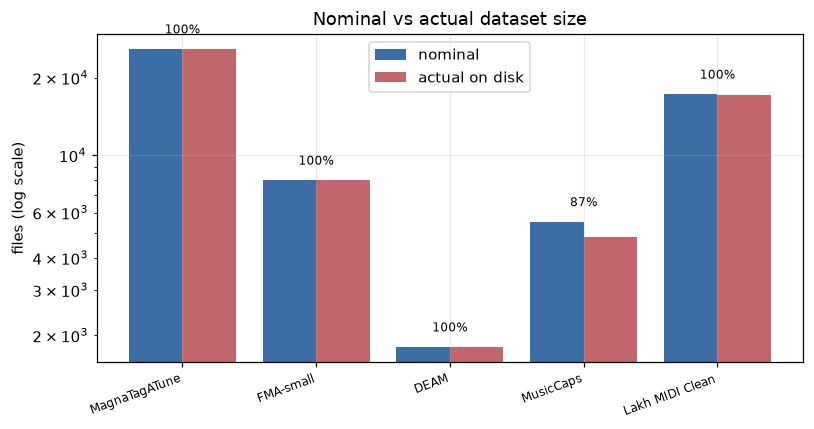

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(survival))
ax.bar(x - 0.2, survival["nominal"], width=0.4, color=PALETTE[0], label="nominal")
ax.bar(x + 0.2, survival["actual"], width=0.4, color=PALETTE[1], label="actual on disk")
ax.set_xticks(x, survival["dataset"], rotation=20, ha="right", fontsize=8)
ax.set_yscale("log")
ax.set_ylabel("files (log scale)")
ax.set_title("Nominal vs actual dataset size")
for xi, (n, a) in enumerate(zip(survival["nominal"], survival["actual"])):
    if n:
        ax.text(xi, max(n, a) * 1.15, f"{100 * a / n:.0f}%", ha="center", fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

## 1b. Split integrity

Two repairs were needed before any of these splits were safe to train on, and
both are reportable findings rather than housekeeping.


In [4]:
if summary_path.exists():
    splits = json.loads(summary_path.read_text(encoding="utf-8"))
    rows = []
    for name, d in splits["datasets"].items():
        if not d.get("rows"):
            continue
        per = d.get("per_split", {})
        rows.append({
            "dataset": name,
            "rows": d["rows"],
            "artists": d.get("artists", 0),
            "train": per.get("train", {}).get("clips", 0),
            "val": per.get("val", {}).get("clips", 0),
            "test": per.get("test", {}).get("clips", 0),
            "moved (in-corpus)": d.get("artist_disjoint_moved", 0),
            "moved (cross-corpus)": d.get("cross_corpus_moved", 0),
            "errata excluded": d.get("errata_excluded", 0),
        })
    display(pd.DataFrame(rows))

    print("1. MagnaTagATune's canonical hex-folder split is NOT artist-disjoint:")
    print("   57 artists have clips in more than one folder. Repairing it moves")
    print("   3,465 of 21,361 clips (16.2%). Both variants are persisted;")
    print("   mtat_manifest_literature.csv is the unrepaired one, for citation only.")
    print()
    print("2. Splits were assigned per corpus independently, so 39 artists sat in")
    print("   two different splits once the manifests were concatenated -- which is")
    print("   the object Task 3 actually loads. Reconciling moved 52 rows.")
    print()
    print("3. FMA ships 3 truncated tracks (99134, 108925, 133297, ~1-2 KB each).")
    print("   not_found.pickle does not cover fma_small, so a size sweep found them.")

    mtat = splits["datasets"]["mtat"]["per_split"]
    print(f"\nCaveat worth reporting: after the repair, MTAT val holds "
          f"{mtat['val']['clips']:,} clips from only {mtat['val']['artists']} artists.")
    print("Artist-disjointness on a 229-artist corpus buys a thin, noisy validation set.")


,dataset,rows,artists,train,val,test,moved (in-corpus),moved (cross-corpus),errata excluded
0,mtat,21358,229,16881,977,3500,0,0,0
1,fma,7994,2305,6398,795,801,0,0,0
2,deam,1802,1469,1277,250,275,0,0,0
3,musiccaps,4830,4830,2095,232,2503,0,0,0
4,lmd,17164,2189,0,0,0,0,0,0
5,mtat_literature,21361,229,15431,1538,4392,0,0,0


1. MagnaTagATune's canonical hex-folder split is NOT artist-disjoint:
   57 artists have clips in more than one folder. Repairing it moves
   3,465 of 21,361 clips (16.2%). Both variants are persisted;
   mtat_manifest_literature.csv is the unrepaired one, for citation only.

2. Splits were assigned per corpus independently, so 39 artists sat in
   two different splits once the manifests were concatenated -- which is
   the object Task 3 actually loads. Reconciling moved 52 rows.

3. FMA ships 3 truncated tracks (99134, 108925, 133297, ~1-2 KB each).
   not_found.pickle does not cover fma_small, so a size sweep found them.

Caveat worth reporting: after the repair, MTAT val holds 977 clips from only 14 artists.
Artist-disjointness on a 229-artist corpus buys a thin, noisy validation set.


## 2. Tag frequency long tail

The reason accuracy is never reported for this task, and the reason synonyms are
merged *before* the top-50 cut rather than after.

In [5]:
from src.splits import MTAT_SYNONYMS, reduce_to_top_k_tags

ann_path = resolve_path(cfg["datasets"]["mtat"]["annotations"])
if ann_path.exists():
    ann = pd.read_csv(ann_path, sep="\t")
    raw_counts = ann.drop(columns=[c for c in ("clip_id", "mp3_path") if c in ann.columns])
    raw_counts = raw_counts.sum().sort_values(ascending=False)

    merged, top_tags = reduce_to_top_k_tags(ann, k=int(cfg["tags"]["top_k"]), merge_synonyms=True)
    merged_counts = merged.drop(columns=["clip_id"]).sum().sort_values(ascending=False)
    print(f"{len(raw_counts)} raw tags -> {len(top_tags)} kept after merging + top-k")
    print(f"most frequent: {merged_counts.index[0]} ({merged_counts.iloc[0]:,} clips)")
    print(f"least frequent kept: {merged_counts.index[-1]} ({merged_counts.iloc[-1]:,} clips)")
    print(f"frequency ratio head:tail = {merged_counts.iloc[0] / max(merged_counts.iloc[-1], 1):.0f}x")
else:
    raw_counts = merged_counts = None
    print(f"MTAT annotations not found at {ann_path}")

10:03:13 | INFO    | gbmc.splits | tag vocabulary: 188 raw -> 133 after synonym merge -> top 50 kept (most frequent guitar @ 4861 clips, least no beat @ 242)


188 raw tags -> 50 kept after merging + top-k
most frequent: guitar (4,861 clips)
least frequent kept: no beat (242 clips)
frequency ratio head:tail = 20x


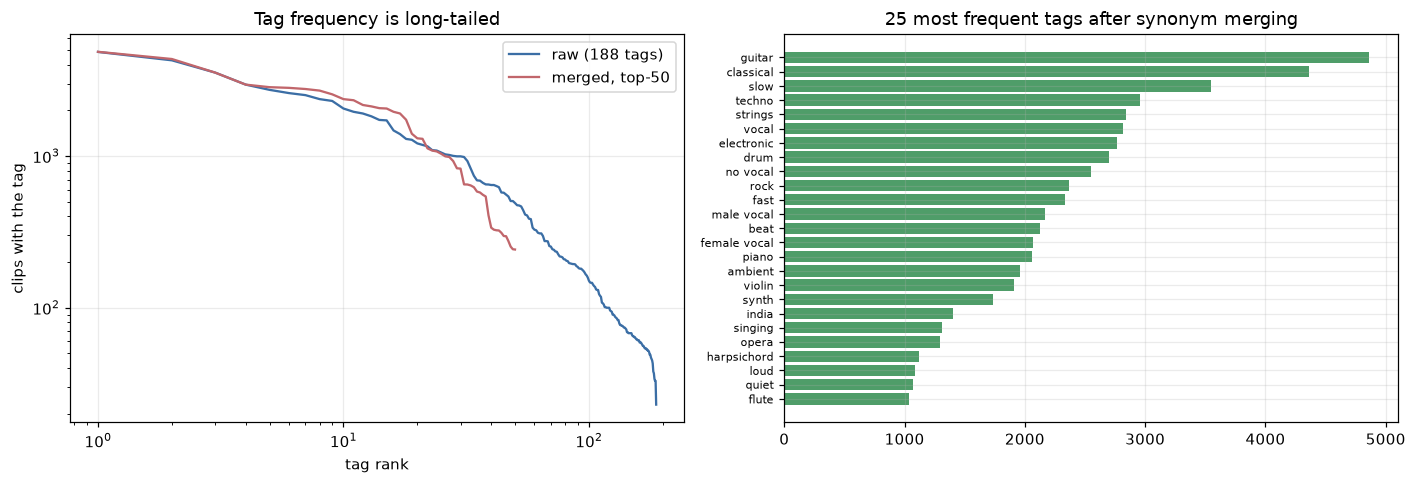

An all-zeros predictor scores 94.6% element accuracy
and 0.00 macro-F1. This is why accuracy is not a metric here.


In [6]:
if merged_counts is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(np.arange(1, len(raw_counts) + 1), raw_counts.values,
                 color=PALETTE[0], label="raw (188 tags)")
    axes[0].plot(np.arange(1, len(merged_counts) + 1), merged_counts.values,
                 color=PALETTE[1], label="merged, top-50")
    axes[0].set_xscale("log"); axes[0].set_yscale("log")
    axes[0].set_xlabel("tag rank"); axes[0].set_ylabel("clips with the tag")
    axes[0].set_title("Tag frequency is long-tailed")
    axes[0].legend()

    top = merged_counts.head(25).iloc[::-1]
    axes[1].barh(top.index, top.values, color=PALETTE[2])
    axes[1].set_title("25 most frequent tags after synonym merging")
    axes[1].tick_params(axis="y", labelsize=7)
    plt.tight_layout(); plt.show()

    # the point of the long tail, stated numerically
    n_clips = len(ann)
    all_zero_accuracy = 1.0 - merged_counts.sum() / (n_clips * len(merged_counts))
    print(f"An all-zeros predictor scores {100 * all_zero_accuracy:.1f}% element accuracy")
    print("and 0.00 macro-F1. This is why accuracy is not a metric here.")

In [7]:
print("Synonym groups folded before counting:")
for canonical, variants in list(MTAT_SYNONYMS.items())[:12]:
    print(f"  {canonical:<14} <- {', '.join(variants)}")
print(f"  ... {len(MTAT_SYNONYMS)} groups in total")

Synonym groups folded before counting:
  beat           <- beats
  chant          <- chanting
  choir          <- choral, chorus
  classical      <- clasical, classic
  drum           <- drums
  electronic     <- electro, electronica, electric
  fast           <- fast beat, quick
  female vocal   <- female, female singer, female singing, female vocals, female voice, woman, woman singing, women
  flute          <- flutes
  guitar         <- guitars
  hard           <- hard rock
  harpsichord    <- harpsicord
  ... 29 groups in total


## 3. Clip duration distributions

Why the segmentation window is 3 s with 50% overlap: it gives 4-32 nodes on
every corpus, which is the range the 2-layer GNN is sized for.

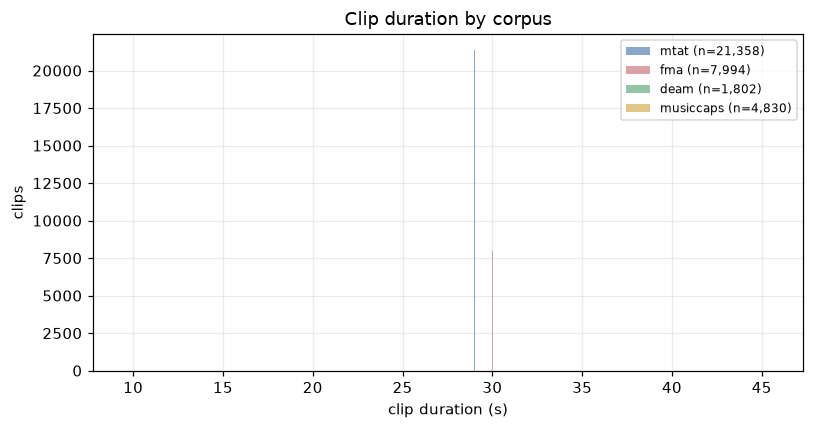

window 3.0 s, hop 1.5 s -> expected node counts:
  mtat       median  29.0 s -> ~18 nodes
  fma        median  30.0 s -> ~19 nodes
  deam       median  45.0 s -> ~29 nodes
  musiccaps  median  10.0 s -> ~5 nodes


In [8]:
durations = {}
splits_dir = resolve_path(cfg["paths"]["splits"])
for name in ("mtat", "fma", "deam", "musiccaps"):
    path = splits_dir / f"{name}_manifest.csv"
    if path.exists():
        frame = pd.read_csv(path)
        values = pd.to_numeric(frame["duration_s"], errors="coerce").dropna()
        if len(values):
            durations[name] = values.to_numpy()

if durations:
    fig, ax = plt.subplots(figsize=(7.5, 4))
    for i, (name, values) in enumerate(durations.items()):
        ax.hist(values, bins=40, alpha=0.6, label=f"{name} (n={len(values):,})",
                color=PALETTE[i % len(PALETTE)])
    ax.set_xlabel("clip duration (s)"); ax.set_ylabel("clips")
    ax.set_title("Clip duration by corpus"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    window = float(cfg["segmentation"]["window_s"]); overlap = float(cfg["segmentation"]["overlap"])
    hop = window * (1 - overlap)
    print(f"window {window} s, hop {hop} s -> expected node counts:")
    for name, values in durations.items():
        nodes = np.clip(np.floor((np.median(values) - window) / hop) + 1,
                        cfg["segmentation"]["min_nodes"], cfg["segmentation"]["max_nodes"])
        print(f"  {name:<10} median {np.median(values):5.1f} s -> ~{int(nodes)} nodes")
else:
    print("no manifests yet -- run `make splits`")

## 4. Tag co-occurrence

Strong off-diagonal blocks are near-duplicate concepts. This is the visual check
that the synonym table is doing its job.

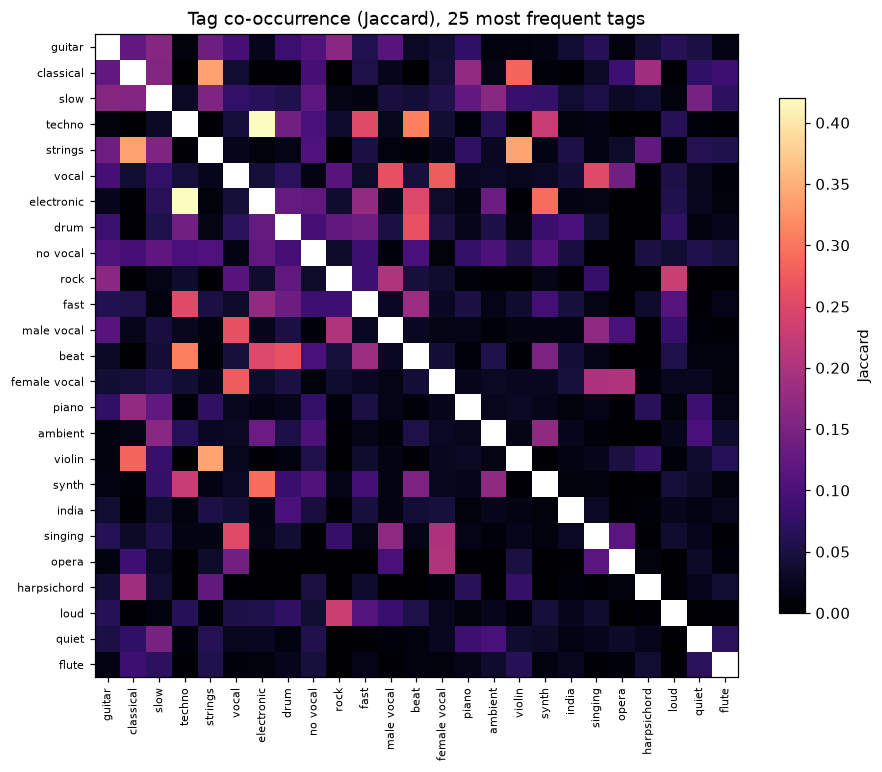

Most co-occurring pairs (candidates for further merging):
  techno           & electronic       J=0.420
  strings          & violin           J=0.340
  classical        & strings          J=0.337
  techno           & beat             J=0.310
  electronic       & synth            J=0.293
  classical        & violin           J=0.284
  vocal            & female vocal     J=0.277
  drum             & beat             J=0.264


In [9]:
if merged_counts is not None:
    top_tags_25 = list(merged_counts.head(25).index)
    matrix = merged[top_tags_25].to_numpy().astype(float)
    counts = matrix.T @ matrix
    marginal = np.diag(counts)
    # Jaccard, so a frequent tag does not dominate every row
    union = marginal[:, None] + marginal[None, :] - counts
    jaccard = np.divide(counts, np.maximum(union, 1))
    np.fill_diagonal(jaccard, np.nan)

    fig, ax = plt.subplots(figsize=(8.5, 7))
    im = ax.imshow(jaccard, cmap="magma", vmin=0)
    ax.set_xticks(range(len(top_tags_25)), top_tags_25, rotation=90, fontsize=7)
    ax.set_yticks(range(len(top_tags_25)), top_tags_25, fontsize=7)
    ax.set_title("Tag co-occurrence (Jaccard), 25 most frequent tags")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Jaccard")
    ax.grid(False)
    plt.tight_layout(); plt.show()

    pairs = [(top_tags_25[i], top_tags_25[j], jaccard[i, j])
             for i in range(len(top_tags_25)) for j in range(i + 1, len(top_tags_25))]
    pairs.sort(key=lambda p: -p[2])
    print("Most co-occurring pairs (candidates for further merging):")
    for a, b, v in pairs[:8]:
        print(f"  {a:<16} & {b:<16} J={v:.3f}")

## 5. Sample graph renders

What the GNN actually consumes: 4-32 nodes, a temporal chain (solid) and k-NN
similarity edges (dashed).

In [10]:
import torch

from src.graph_builder import visualise_graph

sample_dir = ROOT / "data" / "processed" / "sample_graphs"
files = sorted(sample_dir.glob("*.pt"))[:4]
if not files:
    print("run `python scripts/export_sample_graphs.py --synthetic` first")
for path in files:
    data = torch.load(path, weights_only=False)
    print(f"{path.name}: {data.num_nodes} nodes, {data.edge_index.shape[1]} edges, "
          f"x={tuple(data.x.shape)}, edge_attr={tuple(data.edge_attr.shape)}")
    fig = visualise_graph(data)
    plt.show()

B:\CSE425_Project\gnn-bert-music-context\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


000_deam_10.pt: 19 nodes, 119 edges, x=(19, 96), edge_attr=(119, 2)


C:\Users\User\AppData\Local\Temp\ipykernel_3080\253850635.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


001_deam_1000.pt: 19 nodes, 115 edges, x=(19, 96), edge_attr=(115, 2)
002_deam_1001.pt: 19 nodes, 113 edges, x=(19, 96), edge_attr=(113, 2)
003_deam_1002.pt: 19 nodes, 123 edges, x=(19, 96), edge_attr=(123, 2)


In [11]:
# contract audit over every exported sample graph
rows = []
for path in sorted(sample_dir.glob("*.json")):
    if path.name == "index.json":
        continue
    rows.append(json.loads(path.read_text(encoding="utf-8")))
if rows:
    audit = pd.DataFrame(rows)
    display(audit[["track_id", "dataset", "split", "num_nodes", "num_edges",
                   "node_feat_dim", "edge_attr_dim", "min_degree",
                   "n_positive_tags", "y_valence"]].head(20))
    assert (audit["node_feat_dim"] == 96).all(), "contract violation: node features"
    assert (audit["edge_attr_dim"] == 2).all(), "contract violation: edge attributes"
    assert (audit["min_degree"] > 0).all(), "isolated node found"
    print("\nall sample graphs satisfy the data contract")

,track_id,dataset,split,num_nodes,num_edges,node_feat_dim,edge_attr_dim,min_degree,n_positive_tags,y_valence
0,deam_10,deam,train,19,119,96,2,4,-1,4.0
1,deam_1000,deam,train,19,115,96,2,4,-1,6.8
2,deam_1001,deam,val,19,113,96,2,4,-1,4.4
3,deam_1002,deam,test,19,123,96,2,4,-1,4.5
4,deam_1003,deam,train,19,123,96,2,4,-1,5.3
5,fma_000002,fma,train,18,114,96,2,4,-1,NaN
6,fma_000005,fma,train,19,117,96,2,4,-1,NaN
7,fma_000010,fma,test,18,114,96,2,4,-1,NaN
8,fma_000140,fma,train,18,120,96,2,4,-1,NaN
9,fma_000141,fma,train,18,110,96,2,4,-1,NaN



all sample graphs satisfy the data contract


In [12]:
sanity_path = ROOT / "results" / "plots" / "graph_sanity" / "graph_sanity.json"
if sanity_path.exists():
    verdict = json.loads(sanity_path.read_text(encoding="utf-8"))
    print(f"A4.4 gate on {verdict['dataset']}: "
          f"{'PASS' if verdict['passed'] else 'FAIL'}")
    print(f"  long-range edge fraction : {verdict['mean_long_range_fraction']:.3f} "
          f"(need >= {verdict['thresholds']['long_range_fraction']})")
    print(f"  repeat recall            : {verdict['mean_repeat_recall']:.3f} "
          f"(need >= {verdict['thresholds']['repeat_recall']})")
    print(f"  mean similarity lag      : {verdict['mean_similarity_lag']:.2f} segments")
    display(pd.DataFrame(verdict["per_track"])[
        ["track_id", "num_nodes", "n_similarity_edges", "long_range_fraction",
         "repeat_recall", "mean_similarity_lag", "nodes_without_similarity_edges"]])
else:
    print("run `python scripts/graph_sanity.py --dataset mtat` first")


A4.4 gate on mtat: PASS
  long-range edge fraction : 0.858 (need >= 0.3)
  repeat recall            : 0.900 (need >= 0.3)
  mean similarity lag      : 5.76 segments


,track_id,num_nodes,n_similarity_edges,long_range_fraction,repeat_recall,mean_similarity_lag,nodes_without_similarity_edges
0,mtat_10731,18,68,0.823529,1.000000,4.852941,0
1,mtat_11027,18,66,0.818182,0.833333,4.818182,0
2,mtat_10791,18,76,0.815789,0.750000,5.894737,0
3,mtat_10153,18,72,0.833333,0.916667,5.888889,0
4,mtat_11029,18,74,1.000000,1.000000,7.351351,0
